<a href="https://colab.research.google.com/github/vedrode2011-collab/TFIM-trotter-experiment/blob/main/Transverse_Field_Ising_Model_(TFIM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit
!pip install pyzx
!pip install qiskit_aer
!pip install pylatexenc
!pip install pyzx

In [10]:
import pyzx as zx
import numpy as np
from qiskit import QuantumCircuit, qasm2
from qiskit_aer import AerSimulator
import pyzx as zx
from pyzx.circuit import HAD, CNOT



In [20]:
# Model parameters
num_qubits = 4
J = 1.0
g = 0.5
dt = 50

# Initialize circuit
qc = QuantumCircuit(num_qubits)


# 2. Interaction Layer (ZZ-coupling for neighboring spins J)
for i in range(num_qubits - 1):
    qc.cx(i, i + 1)
    qc.rz(2 * J * dt, i + 1)
    qc.cx(i, i + 1)

# 1. Transverse Field Layer (X-rotations for external field g)
for i in range(num_qubits):
    qc.rx(2 * g * dt, i)



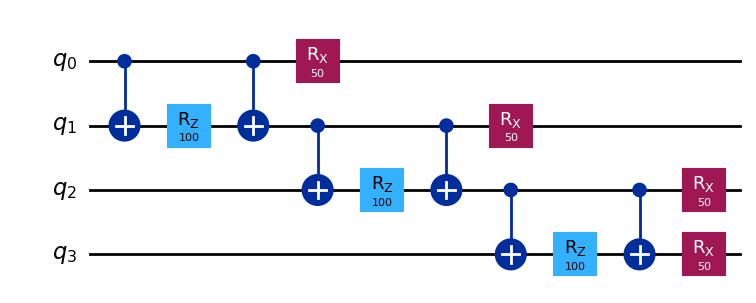

In [21]:
qc.draw("mpl")

Counts: {'0100': 18, '0001': 17, '1100': 2, '1000': 19, '0010': 19, '0000': 925}


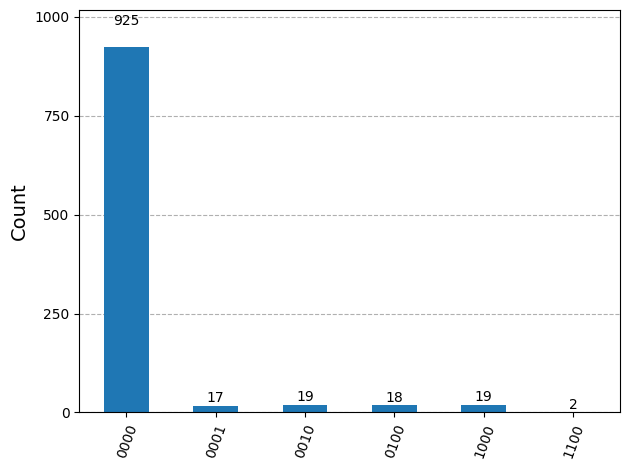

In [19]:
# 3. Measure all qubits
#qc.measure_all()

# Run the simulation
simulator = AerSimulator()
counts = simulator.run(qc, shots=1000).result().get_counts()
print("Counts:", counts)

from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [22]:
qasm_str = qasm2.dumps(qc)

In [23]:
zx_circ = zx.Circuit.from_qasm(qasm_str)
g = zx_circ.to_graph()
zx.draw(g)
print("Circuit Depth:", qc.depth())


Circuit Depth: 10


In [26]:
# 4. Extract the graph back into a new circuit and check its depth
zx.full_reduce(g)
simplified_circuit = zx.extract_circuit(g.copy())
print("Simplified Circuit Depth:", simplified_circuit.depth())
print("Simplified Circuit tcount:", zx.tcount(g))

Simplified Circuit Depth: 23
Simplified Circuit tcount: 7


In [29]:
qsam_str = zx_circ.to_qasm()
qc_2 = QuantumCircuit.from_qasm_str(qsam_str)

Counts: {'0100': 16, '0001': 16, '1000': 21, '0010': 13, '0000': 934}


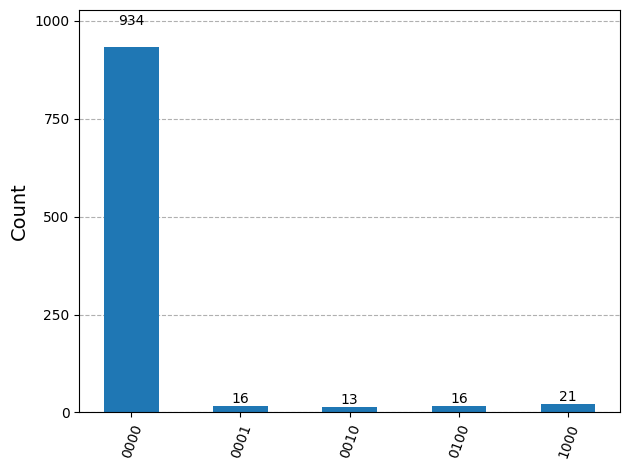

In [30]:
# 3. Measure all qubits
qc_2.measure_all()

# Run the simulation
simulator = AerSimulator() # Fake an IBM device backend
counts = simulator.run(qc_2, shots=1000).result().get_counts()
print("Counts:", counts)

from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [ ]:
# 3. Measure all qubits
qc.measure_all()

# Run the simulation
simulator = AerSimulator()
counts = simulator.run(qc, shots=1000).result().get_counts()
print("Counts:", counts)

from qiskit.visualization import plot_histogram
plot_histogram(counts)

-------------------------------------------------------REAL HARDWARE SECTION FROM HERE -----------------------------------------

In [ ]:
!pip install qiskit qiskit-ibm-runtime

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token="mGdlOGZF8QoiSMlwWclOjjdfb9vuPbFkxFn17Z-JZ2xf",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/2e225be32ba74caabf9d26bc713e18fd:1444aefb-265d-444a-bc49-1f8384db23ea::",
    overwrite=True,
)

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = # service.least_busy(operational=True, simulator=False) choose teh same device
print("Using backend:", backend.name)

In [ ]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qc_isa = pm.run(qc)
qc_isa.draw()

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
job = sampler.run([qc_isa], shots=1000)
print("Job ID:", job.job_id())     # queue can be minutes to hours
result = job.result()

In [ ]:
counts = result[0].data.meas.get_counts()
print("Counts:", counts)

from qiskit.visualization import plot_histogram
plot_histogram(counts)